# Global Air Pollution Analysis (EDA)

This project analyzes global air pollution data using Python to identify pollution patterns across countries, cities, and regions.

## Problem Statement

Air pollution is one of the major environmental challenges affecting public health worldwide. This project aims to analyze global air pollution data to understand pollution patterns across countries, cities, and WHO regions. The analysis focuses on identifying the most polluted regions and examining trends in air pollution levels over time.

## Dataset Description

The dataset used in this project is the Global Air Pollution dataset published by the World Health Organization (WHO).

Key columns in the dataset include:

- WHO Region
- Country Name
- City or Locality
- Measurement Year
- PM2.5 concentration
- PM10 concentration
- NO2 concentration

The dataset contains over 32,000 observations of air pollution measurements collected from cities worldwide.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df=pd.read_excel(r"C:\Users\Darshan_ap\Downloads\who_aap_2021_v9_11august2022.xlsx", sheet_name="AAP_2022_city_v9")

## Data Understanding

In this step we examine the structure of the dataset, including the number of rows, columns, and data types.

In [3]:
df.head()

,WHO Region,ISO3,WHO Country Name,City or Locality,Measurement Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Reference,Number and type of monitoring stations,Version of the database,Status
0,Eastern Mediterranean Region,AFG,Afghanistan,Kabul,2019,119.77,NaN,NaN,18.0,NaN,NaN,"U.S. Department of State, United States Enviro...",NaN,2022,NaN
1,European Region,ALB,Albania,Durres,2015,NaN,17.65,26.63,NaN,NaN,83.961187,European Environment Agency (downloaded in 2021),NaN,2022,NaN
2,European Region,ALB,Albania,Durres,2016,14.32,24.56,24.78,NaN,NaN,87.932605,European Environment Agency (downloaded in 2021),NaN,2022,NaN
3,European Region,ALB,Albania,Elbasan,2015,NaN,NaN,23.96,NaN,NaN,97.853881,European Environment Agency (downloaded in 2021),NaN,2022,NaN
4,European Region,ALB,Albania,Elbasan,2016,NaN,NaN,26.26,NaN,NaN,96.049636,European Environment Agency (downloaded in 2021),NaN,2022,NaN


In [4]:
df.shape

(32191, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32191 entries, 0 to 32190
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   WHO Region                              32190 non-null  object 
 1   ISO3                                    32191 non-null  object 
 2   WHO Country Name                        32191 non-null  object 
 3   City or Locality                        32191 non-null  object 
 4   Measurement Year                        32191 non-null  int64  
 5   PM2.5 (μg/m3)                           15048 non-null  float64
 6   PM10 (μg/m3)                            21109 non-null  float64
 7   NO2 (μg/m3)                             22200 non-null  float64
 8   PM25 temporal coverage (%)              7275 non-null   float64
 9   PM10 temporal coverage (%)              5381 non-null   float64
 10  NO2 temporal coverage (%)               19890 non-null  fl

In [6]:
df.describe()

,Measurement Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Version of the database,Status
count,32191.000000,15048.000000,21109.000000,22200.000000,7275.000000,5381.000000,19890.000000,32191.000000,0.0
mean,2015.579354,22.920320,30.533252,20.619336,90.794096,90.583500,93.696804,2021.744214,NaN
std,2.752654,17.925906,29.312756,12.133388,14.872681,13.816311,10.451751,1.051897,NaN
min,2000.000000,0.010000,1.040000,0.000000,0.000000,2.568493,1.923077,2016.000000,NaN
25%,2014.000000,10.350000,16.980000,12.000000,88.595890,87.945205,93.207763,2022.000000,NaN
50%,2016.000000,16.000000,22.000000,18.800000,97.000000,96.039000,96.369863,2022.000000,NaN
75%,2018.000000,31.000000,31.300000,27.160000,99.000000,98.938000,98.926941,2022.000000,NaN
max,2021.000000,191.900000,540.000000,210.680000,100.000000,100.000000,100.000000,2022.000000,NaN


## Data Cleaning

Data cleaning steps performed:

- Removed unnecessary columns
- Handled missing values
- Removed duplicate records
- Corrected inconsistent region values

In [7]:
df.isnull().sum()

WHO Region                                    1
ISO3                                          0
WHO Country Name                              0
City or Locality                              0
Measurement Year                              0
PM2.5 (μg/m3)                             17143
PM10 (μg/m3)                              11082
NO2 (μg/m3)                                9991
PM25 temporal coverage (%)                24916
PM10 temporal coverage (%)                26810
NO2 temporal coverage (%)                 12301
Reference                                     5
Number and type of monitoring stations    23433
Version of the database                       0
Status                                    32191
dtype: int64

In [8]:
df = df.drop(columns=[
'Reference',
'Number and type of monitoring stations',
'PM25 temporal coverage (%)',
'PM10 temporal coverage (%)',
'NO2 temporal coverage (%)',
'Status'
])

In [9]:
df.shape

(32191, 9)

In [10]:
df.columns

Index(['WHO Region', 'ISO3', 'WHO Country Name', 'City or Locality',
       'Measurement Year', 'PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)',
       'Version of the database'],
      dtype='object')

In [11]:
df['PM2.5 (μg/m3)']=df['PM2.5 (μg/m3)'].fillna(df['PM2.5 (μg/m3)'].mean())

In [12]:
df['PM10 (μg/m3)']=df['PM10 (μg/m3)'].fillna(df['PM10 (μg/m3)'].mean())

In [13]:
df['NO2 (μg/m3)']=df['NO2 (μg/m3)'].fillna(df['NO2 (μg/m3)'].mean())

In [14]:
df['WHO Region']=df['WHO Region'].fillna("unkonown")

In [15]:
df.isnull().sum()

WHO Region                 0
ISO3                       0
WHO Country Name           0
City or Locality           0
Measurement Year           0
PM2.5 (μg/m3)              0
PM10 (μg/m3)               0
NO2 (μg/m3)                0
Version of the database    0
dtype: int64

In [16]:
df.duplicated().sum()

96

In [17]:
df.head()

,WHO Region,ISO3,WHO Country Name,City or Locality,Measurement Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),Version of the database
0,Eastern Mediterranean Region,AFG,Afghanistan,Kabul,2019,119.77000,30.533252,20.619336,2022
1,European Region,ALB,Albania,Durres,2015,22.92032,17.650000,26.630000,2022
2,European Region,ALB,Albania,Durres,2016,14.32000,24.560000,24.780000,2022
3,European Region,ALB,Albania,Elbasan,2015,22.92032,30.533252,23.960000,2022
4,European Region,ALB,Albania,Elbasan,2016,22.92032,30.533252,26.260000,2022


## Exploratory Data Analysis

The exploratory analysis focuses on identifying pollution patterns across countries, cities, and regions.

In [18]:
top_countries=df.groupby('WHO Country Name')['PM2.5 (μg/m3)'].mean().sort_values(ascending=False).head(10)
top_countries

WHO Country Name
Afghanistan     119.770000
Cameroon         82.666667
Bangladesh       75.127000
Mongolia         73.865833
Tajikistan       71.520000
Uganda           69.300000
Pakistan         67.830909
Saudi Arabia     56.173387
Madagascar       46.750000
China            43.067908
Name: PM2.5 (μg/m3), dtype: float64

Text(0, 0.5, 'Country')

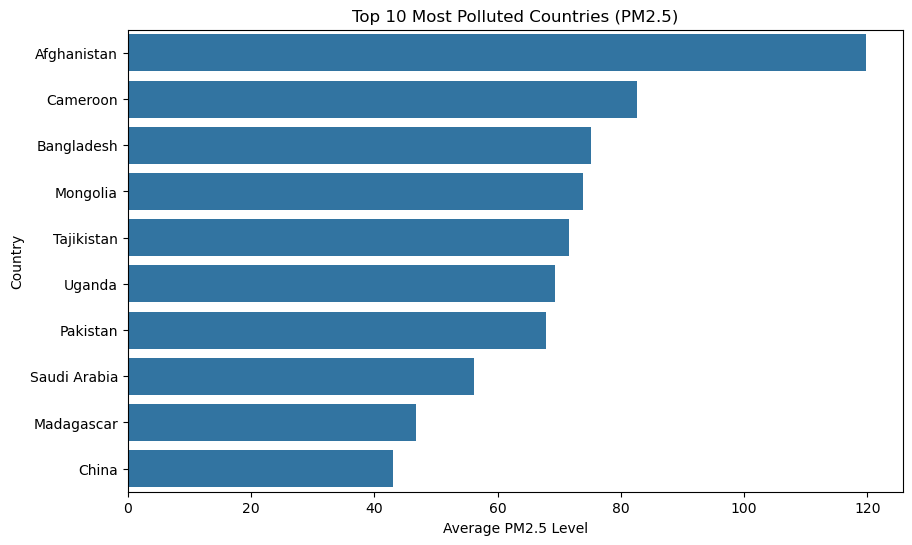

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x = top_countries.values, y = top_countries.index)

plt.title("Top 10 Most Polluted Countries (PM2.5)")
plt.xlabel("Average PM2.5 Level")
plt.ylabel("Country")

Afghanistan shows the highest average PM2.5 concentration (~119 µg/m³), indicating extremely poor air quality. Several developing countries such as Bangladesh, Pakistan, and Mongolia also appear among the most polluted nations.

In [21]:
top_cities= df.groupby('City or Locality')['PM2.5 (μg/m3)'].mean().sort_values(ascending=False).head(10)
top_cities

City or Locality
Bamenda       132.000000
Kabul         119.770000
Hapur         111.000000
Kashi Shi     109.200000
Hotan         108.390000
Rawalpindi    107.000000
Hetian Shi    106.505000
Hetian        105.500000
Kashgar       102.506667
Lahore         95.940000
Name: PM2.5 (μg/m3), dtype: float64

Text(0, 0.5, 'City or Locality')

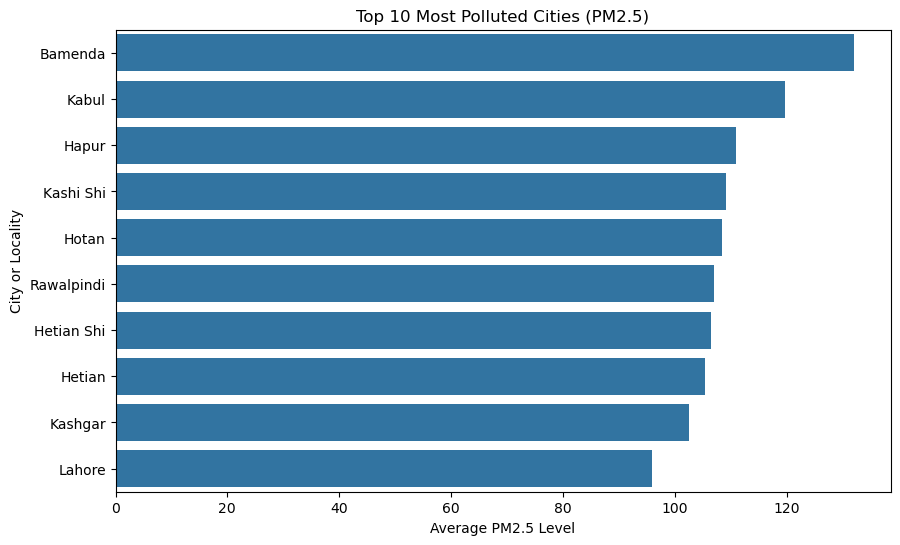

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x = top_cities.values, y = top_cities.index)

plt.title("Top 10 Most Polluted Cities (PM2.5)")
plt.xlabel("Average PM2.5 Level")
plt.ylabel("City or Locality")

The analysis reveals that Bamenda and Kabul have the highest average PM2.5 concentrations among the cities analyzed. Several South Asian cities such as Hapur, Rawalpindi, and Lahore also appear in the top 10, indicating severe air pollution in densely populated regions.

In [24]:
yearly_trend= df.groupby('Measurement Year')['PM2.5 (μg/m3)'].mean().sort_index()
yearly_trend

Measurement Year
2000    22.920320
2001    22.920320
2002    22.920320
2003    22.920320
2004    22.920320
2006    22.920320
2007    22.920320
2008    22.920320
2009    22.920320
2010    21.573839
2011    22.559153
2012    22.613871
2013    20.565148
2014    22.639607
2015    23.823176
2016    23.234231
2017    22.060635
2018    25.172204
2019    22.890141
2020    18.823907
2021    23.269480
Name: PM2.5 (μg/m3), dtype: float64

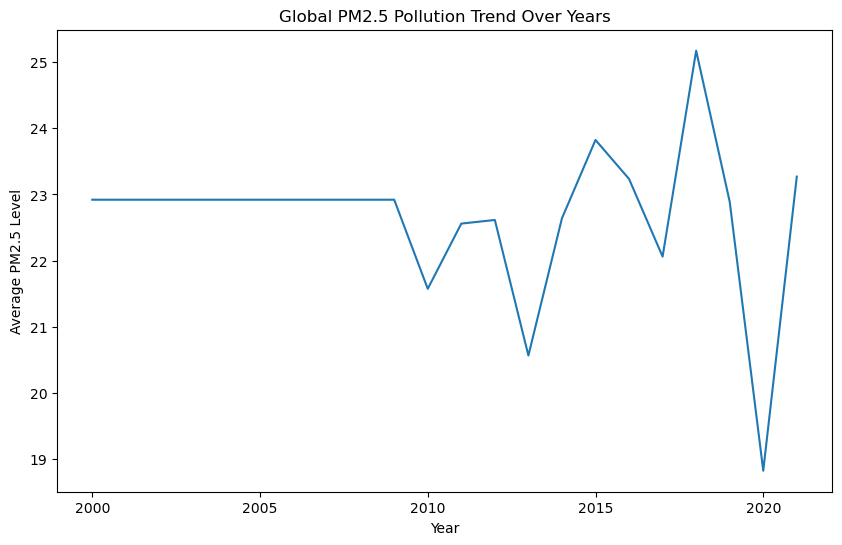

In [25]:
plt.figure(figsize=(10,6))

sns.lineplot(x=yearly_trend.index, y=yearly_trend.values)

plt.title("Global PM2.5 Pollution Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 Level")

plt.show()

he analysis of PM2.5 levels over the years shows how global air pollution has changed over time. Certain years show higher pollution levels, indicating increased industrial activity and urbanization.

In [27]:
df = df[df['WHO Region'] != 'unkonown']

In [28]:
worst_region = df.groupby('WHO Region')['PM2.5 (μg/m3)'].mean().sort_values(ascending=False)
worst_region

WHO Region
Western Pacific Region          39.018294
Eastern Mediterranean Region    30.560935
South East Asia Region          27.302282
African Region                  25.758540
European Region                 19.584153
Region of the Americas          16.742526
Name: PM2.5 (μg/m3), dtype: float64

Text(0, 0.5, 'WHO Region')

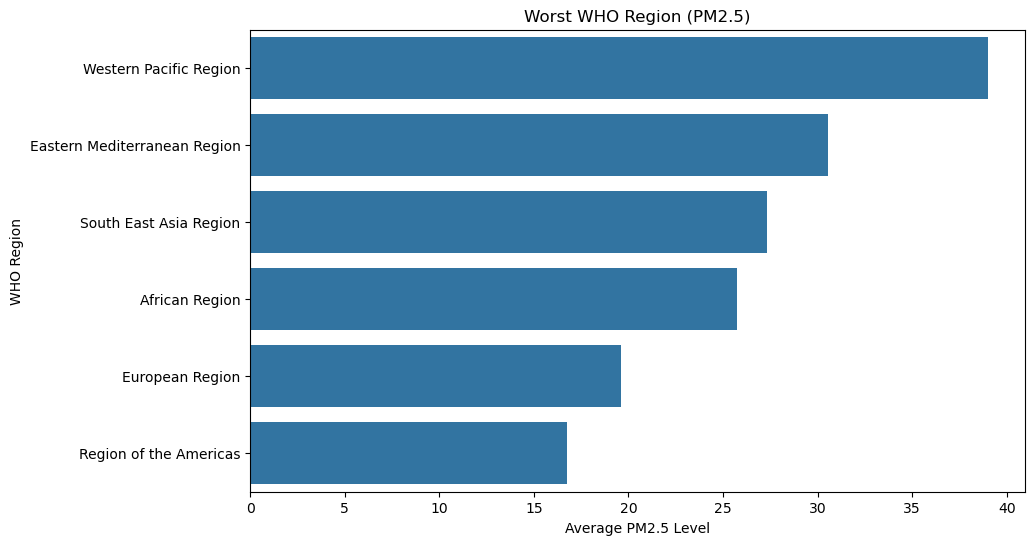

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x = worst_region.values, y = worst_region.index)

plt.title('Worst WHO Region (PM2.5)')
plt.xlabel('Average PM2.5 Level')
plt.ylabel('WHO Region')

The Western Pacific Region shows the highest average PM2.5 levels, indicating significant air pollution challenges in this region. Eastern Mediterranean and South-East Asia regions also exhibit high pollution levels, while the Americas and Europe show comparatively lower PM2.5 concentrations.

In [31]:
pollutants = df[['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']]

Text(0.5, 1.0, 'correlation')

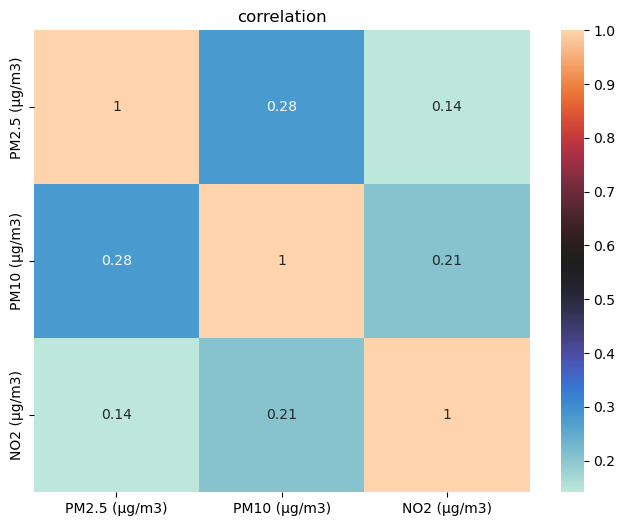

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(pollutants.corr(), annot=True, cmap="icefire")
plt.title("correlation")

The correlation heatmap shows that PM2.5 has a weak relationship with both PM10 and NO2. However, PM10 and NO2 exhibit a very strong correlation, suggesting that these pollutants may originate from similar emission sources such as traffic or industrial activities.

## Key Insights

- Afghanistan shows the highest average PM2.5 pollution levels among countries.
- Cities such as Bamenda and Kabul exhibit extremely high air pollution levels.
- The Western Pacific Region shows the highest regional pollution levels.
- PM10 and NO2 pollutants show strong correlation in the dataset.

## Conclusion

This analysis highlights significant air pollution levels in several regions of the world. Developing regions show higher PM2.5 concentrations, which may be linked to industrial growth, urbanization, and transportation emissions. Understanding these pollution patterns can help policymakers design strategies to improve air quality and public health.